# 🧘 Yoga Pose Detector & Feedback System
### Two-Stage Pipeline: YOLOv8-Pose Keypoint Extraction → Hierarchical DNN Classifier
**Target: ≥ 95% Accuracy on Yoga82 Dataset**

---
**Architecture Overview:**
1. **Stage 1 – Pose Estimation:** YOLOv8-pose extracts 17 COCO keypoints (x, y, confidence) per image
2. **Stage 2 – Feature Engineering:** Raw keypoints → normalized coords + 15 joint angles
3. **Stage 3 – Hierarchical Classification:** Level-1 (6 parent classes) → Level-2 (82 leaf classes)
4. **Stage 4 – Feedback Engine:** Joint angle analysis → corrective text feedback

---

## [Cell 1] — Install Dependencies

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Install all required packages (Mac Safe Versions)
# ─────────────────────────────────────────────────────────────

import subprocess
import sys

packages = [
    'opencv-python',
    'PyYAML',
    'requests',
    'pillow',
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'xgboost',
    'lightgbm',
    'imbalanced-learn',
    'tensorflow',
    'torch',
    'ultralytics',
    'joblib',
    'psutil',  # ADDED: For memory monitoring
    'tqdm'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('✅ All packages installed.')

Installing opencv-python...
Installing PyYAML...
Installing requests...
Installing pillow...
Installing numpy...
Installing pandas...
Installing matplotlib...
Installing seaborn...
Installing scikit-learn...
Installing xgboost...
Installing lightgbm...
Installing imbalanced-learn...
Installing tensorflow...
Installing torch...
Installing ultralytics...
Installing joblib...
Installing psutil...
Installing tqdm...
✅ All packages installed.


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## [Cell 2] — Imports & Global Configuration

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Imports & Global Configuration
# ─────────────────────────────────────────────────────────────

import os
# MAC FIX 1: Prevent OpenMP core dumps from thread collisions
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings, json, math, time, gc
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import joblib

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, top_k_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

# XGBoost / LightGBM
import xgboost as xgb
import lightgbm as lgb

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# YOLOv8
import torch
from ultralytics import YOLO

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# ── CONFIGURATION ──────────────────────────────────────────────
CFG = {
    'DATA_ROOT'       : '/content/drive/MyDrive/Yoga82',          # <-- CHANGE THIS TO YOUR FOLDER
    'TRAIN_DIR'       : 'train',
    'TEST_DIR'        : 'test',
    'VALID_DIR'       : 'valid',
    'KP_CACHE_DIR'    : './keypoint_cache',

    # MAC FIX 2: Use the Nano model to prevent unified memory overload
    'YOLO_MODEL'      : 'yolov8n-pose.pt',
    'YOLO_CONF'       : 0.25,
    'IMG_SIZE'        : 640,

    # Classifier
    'BATCH_SIZE'      : 64,
    'EPOCHS'          : 150,
    'LR'              : 1e-3,
    'DROPOUT'         : 0.40,
    'L2_REG'          : 1e-4,

    # SMOTE / augmentation
    'USE_SMOTE'       : True,
    'AUG_NOISE_STD'   : 0.01,
    'AUG_FLIP'        : True,
    'AUG_SCALE_JITTER': 0.05,
    'MODEL_SAVE_DIR'  : './saved_models',
}

for d in [CFG['KP_CACHE_DIR'], CFG['MODEL_SAVE_DIR']]:
    os.makedirs(d, exist_ok=True)

PARENT_CATEGORIES = {
    'standing' : 0, 'sitting'  : 1, 'balancing': 2,
    'lying'    : 3, 'inverted' : 4, 'resting'  : 5,
}

def get_parent_label(class_name: str) -> int:
    name_lower = class_name.lower()
    for keyword, idx in PARENT_CATEGORIES.items():
        if keyword in name_lower:
            return idx
    if any(k in name_lower for k in ['warrior', 'mountain', 'tree', 'chair', 'forward_bend', 'triangle', 'side_angle']): return 0
    if any(k in name_lower for k in ['lotus', 'staff', 'boat', 'butterfly', 'cow_face', 'hero', 'bound_angle']): return 1
    if any(k in name_lower for k in ['crow', 'crane', 'peacock', 'scale', 'eagle', 'extended_hand']): return 2
    if any(k in name_lower for k in ['corpse', 'sphinx', 'cobra', 'bow', 'bridge', 'camel', 'fish', 'locust']): return 3
    if any(k in name_lower for k in ['headstand', 'shoulderstand', 'plow', 'handstand', 'feathered_peacock']): return 4
    return 5

print('✅ Configuration loaded (Mac Safe).')

✅ Configuration loaded (Mac Safe).


## [Cell 3] — Data Inventory & Class Distribution

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Data Inventory & Class Distribution Analysis
# ─────────────────────────────────────────────────────────────

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def scan_split(split_name: str) -> pd.DataFrame:
    root = Path(CFG['DATA_ROOT']) / split_name
    records = []
    if not root.exists():
        print(f"⚠️ Warning: Directory not found - {root}")
        return pd.DataFrame()

    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir(): continue
        class_name = class_dir.name
        parent_id  = get_parent_label(class_name)
        for img_path in class_dir.rglob('*'):
            if img_path.suffix.lower() in VALID_EXTS:
                records.append({
                    'path'       : str(img_path),
                    'class_name' : class_name,
                    'parent_id'  : parent_id,
                    'split'      : split_name,
                })
    return pd.DataFrame(records)

df_train = scan_split(CFG['TRAIN_DIR'])
df_valid = scan_split(CFG['VALID_DIR'])
df_test  = scan_split(CFG['TEST_DIR'])

if df_train.empty:
    raise ValueError("Train dataframe is empty! Check your CFG['DATA_ROOT'] path.")

le_leaf   = LabelEncoder()
all_names = pd.concat([df_train, df_valid, df_test])['class_name'].values
le_leaf.fit(all_names)

for df in [df_train, df_valid, df_test]:
    df['label'] = le_leaf.transform(df['class_name'])

N_CLASSES = len(le_leaf.classes_)
print(f'Total classes    : {N_CLASSES}')
print(f'Train images     : {len(df_train):,}')
print(f'Valid images     : {len(df_valid):,}')
print(f'Test  images     : {len(df_test):,}')

joblib.dump(le_leaf, os.path.join(CFG['MODEL_SAVE_DIR'], 'label_encoder.pkl'))
print('✅ Label encoder saved.')

Total classes    : 82
Train images     : 11,652
Valid images     : 3,361
Test  images     : 1,764
✅ Label encoder saved.


## [Cell 4] — YOLOv8-Pose Keypoint Extraction Engine

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — YOLOv8-Pose Extraction (ULTRA-SAFE MAC VERSION v2)
# ─────────────────────────────────────────────────────────────

# MAC FIX 3: Stop OpenCV from spawning threads and crashing macOS
cv2.setNumThreads(0)

# Load YOLOv8-pose with minimal memory footprint
def load_yolo_safe():
    global yolo_model
    yolo_model = YOLO(CFG['YOLO_MODEL'])
    print(f'✅ YOLOv8-pose loaded: {CFG["YOLO_MODEL"]}')

load_yolo_safe()

N_KP    = 17
KP_DIM  = N_KP * 3

def normalize_keypoints(kps: np.ndarray) -> np.ndarray:
    kps = kps.copy().reshape(N_KP, 3)
    xy   = kps[:, :2]
    conf = kps[:, 2:]

    L_hip, R_hip   = xy[11], xy[12]
    hip_center      = (L_hip + R_hip) / 2.0
    xy -= hip_center

    L_sh, R_sh = xy[5], xy[6]
    torso_len  = (np.linalg.norm(L_sh - xy[11]) + np.linalg.norm(R_sh - xy[12])) / 2.0
    if torso_len > 1e-6:
        xy /= torso_len

    return np.concatenate([xy, conf], axis=1).flatten()

def extract_keypoints_from_image(img_path: str) -> np.ndarray | None:
    """Extract keypoints from a single image - ULTRA MEMORY SAFE"""
    img = cv2.imread(img_path)
    if img is None:
        return None

    try:
        # MAC FIX 4: Prevent PyTorch gradient memory hoarding
        with torch.no_grad():
            results = yolo_model(
                img,
                imgsz=CFG['IMG_SIZE'],
                conf=CFG['YOLO_CONF'],
                verbose=False,
                device='cpu'  # MAC FIX 5: Force CPU execution
            )

        result = results[0]
        if result.keypoints is None or len(result.keypoints.data) == 0:
            del img, results, result
            gc.collect()
            return None

        kp_data = result.keypoints.data.cpu().numpy()
        mean_confs = kp_data[:, :, 2].mean(axis=1)
        best_idx   = int(np.argmax(mean_confs))
        kps_raw    = kp_data[best_idx].copy()  # Make local copy

        out_kps = normalize_keypoints(kps_raw.flatten())

        # MAC FIX 6: AGGRESSIVE memory cleanup - delete EVERYTHING immediately
        del img, results, result, kp_data, kps_raw, mean_confs, best_idx
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

        return out_kps
    except Exception as e:
        print(f'   Error processing {img_path}: {e}')
        gc.collect()
        return None

def extract_and_cache_split(df: pd.DataFrame, cache_path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract keypoints from all images in a dataframe - ULTRA MEMORY SAFE"""
    if os.path.exists(cache_path):
        print(f'   → Loading cached keypoints from {cache_path}')
        cache = np.load(cache_path, allow_pickle=True)
        X = np.array(cache['X'], copy=True, dtype=np.float32)
        y_leaf = np.array(cache['y_leaf'], copy=True, dtype=np.int32)
        y_parent = np.array(cache['y_parent'], copy=True, dtype=np.int32)
        cache.close()
        del cache
        gc.collect()
        return X, y_leaf, y_parent

    X, y_leaf, y_parent = [], [], []
    failed = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Extracting keypoints', disable=False):
        kp = extract_keypoints_from_image(row['path'])
        if kp is None:
            failed += 1
        else:
            X.append(kp)
            y_leaf.append(row['label'])
            y_parent.append(row['parent_id'])

        # MAC FIX 7: ULTRA AGGRESSIVE - garbage collect every 10 images
        if (idx + 1) % 10 == 0:
            gc.collect()

    print(f'   → Converting to numpy arrays...')
    X        = np.array(X,        dtype=np.float32)
    y_leaf   = np.array(y_leaf,   dtype=np.int32)
    y_parent = np.array(y_parent, dtype=np.int32)

    print(f'   → Saving compressed cache to {cache_path}')
    np.savez_compressed(cache_path, X=X, y_leaf=y_leaf, y_parent=y_parent)
    print(f'   ✓ Saved cache ({X.nbytes / 1024 / 1024:.1f} MB)')
    print(f'   ✓ Failed detections: {failed}/{len(df)} ({100*failed/len(df):.1f}%)')

    gc.collect()
    return X, y_leaf, y_parent

print('✅ Keypoint extraction engine ready (Ultra-Safe Mac v2).')

✅ YOLOv8-pose loaded: yolov8n-pose.pt
✅ Keypoint extraction engine ready (Ultra-Safe Mac v2).


## [Cell 5] — Run Keypoint Extraction on All Splits

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 5a — Extract & Cache TRAIN split ONLY
# ─────────────────────────────────────────────────────────────
# CRITICAL: Process each split separately to avoid memory accumulation
# RUN ONLY THIS CELL, then wait for completion, then run 5b, then 5c

import psutil
import os as os_module

cache_dir = CFG['KP_CACHE_DIR']

def print_memory_usage(label=''):
    process = psutil.Process(os_module.getpid())
    mem_info = process.memory_info()
    print(f'   [{label}] Memory: {mem_info.rss / 1024 / 1024:.1f} MB')

# CRITICAL: Ensure YOLO is loaded fresh
print('Verifying YOLO model is loaded...')
if 'yolo_model' not in globals():
    load_yolo_safe()
print_memory_usage('YOLO_LOADED')

print('=' * 60)
print('TRAIN SPLIT EXTRACTION')
print('=' * 60)
print_memory_usage('START')

X_train, y_train, yp_train = extract_and_cache_split(
    df_train, os.path.join(cache_dir, 'train_keypoints.npz')
)

print_memory_usage('AFTER_TRAIN')
print(f'✅ X_train shape: {X_train.shape}')
print('\n' + '='*60)
print('⚠️  NEXT STEP: Run Cell 5b (VALID split)')
print('='*60)

Verifying YOLO model is loaded...
   [YOLO_LOADED] Memory: 1160.4 MB
TRAIN SPLIT EXTRACTION
   [START] Memory: 1160.4 MB


Extracting keypoints: 100%|██████████| 11652/11652 [1:33:33<00:00,  2.08it/s]


   → Converting to numpy arrays...
   → Saving compressed cache to ./keypoint_cache/train_keypoints.npz
   ✓ Saved cache (2.1 MB)
   ✓ Failed detections: 943/11652 (8.1%)
   [AFTER_TRAIN] Memory: 1467.4 MB
✅ X_train shape: (10709, 51)

⚠️  NEXT STEP: Run Cell 5b (VALID split)


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 5b — Extract & Cache VALID split ONLY
# ─────────────────────────────────────────────────────────────
# RUN THIS AFTER CELL 5a COMPLETES

# Ensure YOLO is loaded fresh
print('Verifying YOLO model is loaded...')
if 'yolo_model' not in globals():
    load_yolo_safe()
print_memory_usage('YOLO_LOADED')

print('=' * 60)
print('VALID SPLIT EXTRACTION')
print('=' * 60)
print_memory_usage('START')

X_valid, y_valid, yp_valid = extract_and_cache_split(
    df_valid, os.path.join(cache_dir, 'valid_keypoints.npz')
)

print_memory_usage('AFTER_VALID')
print(f'✅ X_valid shape: {X_valid.shape}')
print('\n' + '='*60)
print('⚠️  NEXT STEP: Run Cell 5c (TEST split)')
print('='*60)

Verifying YOLO model is loaded...
   [YOLO_LOADED] Memory: 1467.4 MB
VALID SPLIT EXTRACTION
   [START] Memory: 1467.4 MB


Extracting keypoints: 100%|██████████| 3361/3361 [30:40<00:00,  1.83it/s]


   → Converting to numpy arrays...
   → Saving compressed cache to ./keypoint_cache/valid_keypoints.npz
   ✓ Saved cache (0.6 MB)
   ✓ Failed detections: 324/3361 (9.6%)
   [AFTER_VALID] Memory: 1526.2 MB
✅ X_valid shape: (3037, 51)

⚠️  NEXT STEP: Run Cell 5c (TEST split)


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 5c — Extract & Cache TEST split ONLY
# ─────────────────────────────────────────────────────────────
# RUN THIS AFTER CELL 5b COMPLETES

# Ensure YOLO is loaded fresh
print('Verifying YOLO model is loaded...')
if 'yolo_model' not in globals():
    load_yolo_safe()
print_memory_usage('YOLO_LOADED')

print('=' * 60)
print('TEST SPLIT EXTRACTION')
print('=' * 60)
print_memory_usage('START')

X_test, y_test, yp_test = extract_and_cache_split(
    df_test, os.path.join(cache_dir, 'test_keypoints.npz')
)

print_memory_usage('AFTER_TEST')
print(f'✅ X_test shape: {X_test.shape}')

print('\n' + '='*60)
print('✅ EXTRACTION COMPLETE!')
print('='*60)
print(f'Summary:')
print(f'   X_train: {X_train.shape}  ({X_train.nbytes / 1024 / 1024:.1f} MB)')
print(f'   X_valid: {X_valid.shape}  ({X_valid.nbytes / 1024 / 1024:.1f} MB)')
print(f'   X_test:  {X_test.shape}   ({X_test.nbytes / 1024 / 1024:.1f} MB)')
print('='*60)

Verifying YOLO model is loaded...
   [YOLO_LOADED] Memory: 1526.5 MB
TEST SPLIT EXTRACTION
   [START] Memory: 1526.5 MB


Extracting keypoints: 100%|██████████| 1764/1764 [14:03<00:00,  2.09it/s]


   → Converting to numpy arrays...
   → Saving compressed cache to ./keypoint_cache/test_keypoints.npz
   ✓ Saved cache (0.3 MB)
   ✓ Failed detections: 173/1764 (9.8%)
   [AFTER_TEST] Memory: 1493.4 MB
✅ X_test shape: (1591, 51)

✅ EXTRACTION COMPLETE!
Summary:
   X_train: (10709, 51)  (2.1 MB)
   X_valid: (3037, 51)  (0.6 MB)
   X_test:  (1591, 51)   (0.3 MB)


## [Cell 6] — Feature Engineering: Joint Angles & Enhanced Feature Vector

In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Feature Engineering
#
# We compute 15 biomechanically meaningful joint angles from
# the 17 COCO keypoints. Angles encode pose configuration
# independently of body position in the frame — crucial for
# distinguishing subtle pose differences.
#
# Final feature vector per sample:
#   51 (raw kp) + 15 (angles) = 66 features
#   (confidence scores act as implicit keypoint quality weights)
# ─────────────────────────────────────────────────────────────

# COCO keypoint indices
KP = {
    'nose':0,'L_eye':1,'R_eye':2,'L_ear':3,'R_ear':4,
    'L_sh':5,'R_sh':6,'L_el':7,'R_el':8,
    'L_wr':9,'R_wr':10,'L_hip':11,'R_hip':12,
    'L_kn':13,'R_kn':14,'L_an':15,'R_an':16
}

# Each triple (A, B, C) → angle at joint B between rays B→A and B→C
ANGLE_TRIPLETS = [
    # Arms
    ('L_sh',  'L_el',  'L_wr'),   # left elbow
    ('R_sh',  'R_el',  'R_wr'),   # right elbow
    ('L_el',  'L_sh',  'L_hip'), # left shoulder
    ('R_el',  'R_sh',  'R_hip'), # right shoulder
    # Torso
    ('L_sh',  'L_hip', 'L_kn'),  # left torso/hip
    ('R_sh',  'R_hip', 'R_kn'),  # right torso/hip
    # Legs
    ('L_hip', 'L_kn',  'L_an'),  # left knee
    ('R_hip', 'R_kn',  'R_an'),  # right knee
    ('L_kn',  'L_an',  'L_hip'), # left ankle
    ('R_kn',  'R_an',  'R_hip'), # right ankle
    # Hip alignment
    ('L_sh',  'L_hip', 'R_hip'), # left hip-shoulder
    ('R_sh',  'R_hip', 'L_hip'), # right hip-shoulder
    # Spine proxy
    ('nose',  'L_sh',  'L_hip'), # left spine
    ('nose',  'R_sh',  'R_hip'), # right spine
    # Shoulder width vs hip tilt
    ('L_sh',  'R_sh',  'R_hip'), # shoulder-hip triangle
]
N_ANGLES = len(ANGLE_TRIPLETS)


def angle_between(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
    """
    Compute the angle (degrees) at joint B between vectors B→A and B→C.
    Returns -1 if any point is at origin (undetected keypoint).
    """
    ba = a - b
    bc = c - b
    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)
    if norm_ba < 1e-6 or norm_bc < 1e-6:
        return -1.0   # sentinel for undetected / degenerate
    cos_angle = np.clip(np.dot(ba, bc) / (norm_ba * norm_bc), -1.0, 1.0)
    return math.degrees(math.acos(cos_angle))


def compute_angle_features(kp_vec: np.ndarray) -> np.ndarray:
    """
    Given a 51-d keypoint vector, compute 15 joint angles.
    Returns a 15-d array (angles in degrees, sentinel -1 for missing).
    """
    kps = kp_vec.reshape(N_KP, 3)  # (17, 3)
    xy  = kps[:, :2]               # (17, 2)
    angles = []
    for (na, nb, nc) in ANGLE_TRIPLETS:
        a = xy[KP[na]]; b = xy[KP[nb]]; c = xy[KP[nc]]
        angles.append(angle_between(a, b, c))
    return np.array(angles, dtype=np.float32)


def build_feature_matrix(X_raw: np.ndarray) -> np.ndarray:
    """
    Concatenate raw keypoints with angle features.
    Input:  (N, 51)
    Output: (N, 66)
    """
    angles = np.array([compute_angle_features(row) for row in X_raw], dtype=np.float32)
    return np.concatenate([X_raw, angles], axis=1)


print('Computing angle features for all splits...')
F_train = build_feature_matrix(X_train)
F_valid = build_feature_matrix(X_valid)
F_test  = build_feature_matrix(X_test)
print(f'✅ Feature matrix shape: {F_train.shape}  (51 keypoints + {N_ANGLES} angles)')

# Standardize features (fit ONLY on train)
scaler = StandardScaler()
F_train_sc = scaler.fit_transform(F_train)
F_valid_sc = scaler.transform(F_valid)
F_test_sc  = scaler.transform(F_test)

joblib.dump(scaler, os.path.join(CFG['MODEL_SAVE_DIR'], 'scaler.pkl'))
print('✅ Scaler saved.')

Computing angle features for all splits...
✅ Feature matrix shape: (10709, 66)  (51 keypoints + 15 angles)
✅ Scaler saved.


## [Cell 7] — Keypoint Augmentation

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Keypoint-Space Data Augmentation
#
# Three augmentation strategies applied to the TRAINING set:
#   1. Gaussian noise on x,y coords  → robust to jitter
#   2. Horizontal flip (mirror L↔R) → doubles training data
#   3. Scale jitter (±5%)           → robust to body size
#
# These are applied to the raw 51-d keypoint vectors BEFORE
# angle computation so angles remain geometrically consistent.
# ─────────────────────────────────────────────────────────────

# Horizontal flip: swap left↔right keypoints
# COCO symmetric pairs: (1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)
FLIP_PAIRS = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]

def flip_keypoints(kp_vec: np.ndarray) -> np.ndarray:
    """Mirror keypoints horizontally (negate x, swap L/R pairs)."""
    kps = kp_vec.reshape(N_KP, 3).copy()
    kps[:, 0] = -kps[:, 0]   # negate x (already hip-centered)
    for (i, j) in FLIP_PAIRS:
        kps[[i, j]] = kps[[j, i]]
    return kps.flatten()


def augment_keypoints(
    X: np.ndarray, y: np.ndarray, yp: np.ndarray,
    noise_std: float = CFG['AUG_NOISE_STD'],
    scale_jitter: float = CFG['AUG_SCALE_JITTER'],
    do_flip: bool = CFG['AUG_FLIP']
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Return augmented copies concatenated with originals.
    """
    aug_X, aug_y, aug_yp = [X.copy()], [y.copy()], [yp.copy()]

    # 1. Gaussian noise
    noisy = X.copy()
    xy_mask = np.tile([1,1,0], N_KP).astype(bool)  # only x,y; not confidence
    noisy[:, xy_mask] += np.random.normal(0, noise_std, noisy[:, xy_mask].shape)
    aug_X.append(noisy); aug_y.append(y); aug_yp.append(yp)

    # 2. Horizontal flip
    if do_flip:
        flipped = np.array([flip_keypoints(row) for row in X])
        aug_X.append(flipped); aug_y.append(y); aug_yp.append(yp)

    # 3. Scale jitter
    scales = 1.0 + np.random.uniform(-scale_jitter, scale_jitter, (len(X), 1))
    scaled = X.copy()
    scaled[:, xy_mask] *= scales
    aug_X.append(scaled); aug_y.append(y); aug_yp.append(yp)

    return np.vstack(aug_X), np.hstack(aug_y), np.hstack(aug_yp)


print('Applying keypoint augmentations on training set...')
X_train_aug, y_train_aug, yp_train_aug = augment_keypoints(X_train, y_train, yp_train)
print(f'   Before augmentation : {X_train.shape[0]:,} samples')
print(f'   After  augmentation : {X_train_aug.shape[0]:,} samples  (×{X_train_aug.shape[0]//X_train.shape[0]})')

# Rebuild feature matrix from augmented raw keypoints
print('Rebuilding feature matrix with angles...')
F_train_aug = build_feature_matrix(X_train_aug)
F_train_aug_sc = scaler.transform(F_train_aug)
print(f'✅ Augmented feature matrix: {F_train_aug.shape}')

Applying keypoint augmentations on training set...
   Before augmentation : 10,709 samples
   After  augmentation : 42,836 samples  (×4)
Rebuilding feature matrix with angles...
✅ Augmented feature matrix: (42836, 66)


## [Cell 8] — SMOTE for Class Imbalance

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — SMOTE Oversampling
#
# Applied AFTER augmentation on the scaled feature matrix.
# SMOTE synthesizes new minority-class samples by interpolating
# between real neighbors in feature space.
#
# Tip: Set k_neighbors=3 for very rare classes (< 5 samples).
# ─────────────────────────────────────────────────────────────

if CFG['USE_SMOTE']:
    print('Applying SMOTE oversampling...')
    # Determine minimum samples per class to set k_neighbors
    min_count = np.bincount(y_train_aug).min()
    k_neighbors = max(1, min(5, min_count - 1))
    print(f'   Min class count: {min_count} → k_neighbors={k_neighbors}')

    smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
    F_train_sm, y_train_sm = smote.fit_resample(F_train_aug_sc, y_train_aug)

    # Rebuild parent labels for the SMOTE-generated samples
    # (we can't recover exact parent labels for synthetic points;
    #  use the parent of the closest real neighbor = same as source class)
    yp_train_sm = np.array(
        [get_parent_label(le_leaf.inverse_transform([lbl])[0]) for lbl in y_train_sm],
        dtype=np.int32
    )

    print(f'   Before SMOTE: {F_train_aug_sc.shape[0]:,} samples')
    print(f'   After  SMOTE: {F_train_sm.shape[0]:,} samples')
else:
    F_train_sm, y_train_sm, yp_train_sm = F_train_aug_sc, y_train_aug, yp_train_aug
    print('SMOTE disabled — using augmented data as-is.')

# Shuffle
perm = np.random.permutation(len(F_train_sm))
F_train_sm  = F_train_sm[perm]
y_train_sm  = y_train_sm[perm]
yp_train_sm = yp_train_sm[perm]

N_FEAT = F_train_sm.shape[1]
print(f'✅ Final training set: {F_train_sm.shape}  features={N_FEAT}')

Applying SMOTE oversampling...
   Min class count: 96 → k_neighbors=5
   Before SMOTE: 42,836 samples
   After  SMOTE: 108,568 samples
✅ Final training set: (108568, 66)  features=66


## [Cell 9] — Build the Hierarchical DNN Classifier

In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Hierarchical DNN Architecture
#
# Two separate DNNs:
#   • Level-1 (parent_model): 6-class (broad category)
#   • Level-2 (leaf_model)  : 82-class (specific pose)
#     The leaf model receives the 66-d feature vector AND
#     the 6-d soft probability output of the parent model
#     as extra context → total input = 72 features.
#
# Architecture is deliberately lightweight to avoid overfitting
# on a tabular feature vector (no millions of pixels).
# ─────────────────────────────────────────────────────────────

N_PARENTS = len(PARENT_CATEGORIES)

def build_parent_model(input_dim: int, n_classes: int = N_PARENTS) -> keras.Model:
    """
    Level-1 model: predicts the 6 broad pose categories.
    Architecture: Dense(256) → BN → Dropout → Dense(128) → BN → Dropout → Softmax(6)
    """
    inp = layers.Input(shape=(input_dim,), name='keypoint_features')
    x   = layers.Dense(256, kernel_regularizer=regularizers.l2(CFG['L2_REG']))(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('swish')(x)
    x   = layers.Dropout(CFG['DROPOUT'])(x)

    x   = layers.Dense(128, kernel_regularizer=regularizers.l2(CFG['L2_REG']))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('swish')(x)
    x   = layers.Dropout(CFG['DROPOUT'] * 0.5)(x)

    out = layers.Dense(n_classes, activation='softmax', name='parent_probs')(x)
    return keras.Model(inp, out, name='parent_model')


def build_leaf_model(feat_dim: int, parent_probs_dim: int, n_classes: int) -> keras.Model:
    """
    Level-2 model: predicts all 82 yoga poses.
    Input = [66-d features] + [6-d parent soft probs]
    Architecture: Dense(512) → BN → skip → Dense(512) → BN → Dense(256) → Softmax(82)
    """
    feat_inp   = layers.Input(shape=(feat_dim,),         name='features')
    parent_inp = layers.Input(shape=(parent_probs_dim,), name='parent_probs')

    combined = layers.Concatenate()([feat_inp, parent_inp])

    # Block 1
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(CFG['L2_REG']))(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(CFG['DROPOUT'])(x)

    # Residual block
    x_skip = layers.Dense(512)(combined)  # project input to match dim
    x2 = layers.Dense(512, kernel_regularizer=regularizers.l2(CFG['L2_REG']))(x)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation('swish')(x2)
    x2 = layers.Dropout(CFG['DROPOUT'])(x2)
    x  = layers.Add()([x2, x_skip])

    # Block 3
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(CFG['L2_REG']))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(CFG['DROPOUT'] * 0.5)(x)

    out = layers.Dense(n_classes, activation='softmax', name='pose_probs')(x)
    return keras.Model([feat_inp, parent_inp], out, name='leaf_model')


parent_model = build_parent_model(N_FEAT)
leaf_model   = build_leaf_model(N_FEAT, N_PARENTS, N_CLASSES)

parent_model.summary()
print('\n')
leaf_model.summary()

Model: "parent_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keypoint_features (InputLayer)  │ (None, 66)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ parent_probs (Dense)            │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,358 (204.52 KB)

 Trainable params: 51,590 (201.52 KB)

 Non-trainable params: 768 (3.00 KB)

Model: "leaf_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 66)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ parent_probs        │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ features[0][0],   │
│ (Concatenate)       │                   │            │ parent_probs[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │     37,376 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    262,656 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │     37,376 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512)       │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pose_probs (Dense)  │ (None, 82)        │     21,074 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 494,930 (1.89 MB)

 Trainable params: 492,370 (1.88 MB)

 Non-trainable params: 2,560 (10.00 KB)

## [Cell 10] — Train the Level-1 Parent Classifier

Parent class weights: {0: '0.80', 1: '1.53', 2: '3.05', 3: '1.22', 4: '3.23', 5: '0.38'}

Training Level-1 (parent) model...
Epoch 1/150
1679/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4321 - loss: 1.2777

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4809 - loss: 1.1444 - val_accuracy: 0.5245 - val_loss: 1.1873 - learning_rate: 0.0010
Epoch 2/150
1693/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5433 - loss: 0.9795

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5530 - loss: 0.9581 - val_accuracy: 0.5706 - val_loss: 1.1008 - learning_rate: 0.0010
Epoch 3/150
1695/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5786 - loss: 0.9010

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5847 - loss: 0.8878 - val_accuracy: 0.5808 - val_loss: 1.0723 - learning_rate: 0.0010
Epoch 4/150
1692/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6047 - loss: 0.8475

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6095 - loss: 0.8384 - val_accuracy: 0.6141 - val_loss: 1.0294 - learning_rate: 0.0010
Epoch 5/150
1693/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6226 - loss: 0.8058

...

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7784 - loss: 0.4897 - val_accuracy: 0.6941 - val_loss: 0.9580 - learning_rate: 2.5000e-04
Epoch 47/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7787 - loss: 0.4889 - val_accuracy: 0.6862 - val_loss: 0.9700 - learning_rate: 2.5000e-04
Epoch 48/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7781 - loss: 0.4877 - val_accuracy: 0.6938 - val_loss: 0.9723 - learning_rate: 2.5000e-04
Epoch 49/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7774 - loss: 0.4893 - val_accuracy: 0.6925 - val_loss: 0.9644 - learning_rate: 2.5000e-04
Epoch 50/150
1693/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7810 - loss: 0.4793

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7800 - loss: 0.4810 - val_accuracy: 0.6984 - val_loss: 0.9605 - learning_rate: 2.5000e-04
Epoch 51/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7804 - loss: 0.4847 - val_accuracy: 0.6944 - val_loss: 0.9676 - learning_rate: 2.5000e-04
Epoch 52/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7848 - loss: 0.4712 - val_accuracy: 0.6944 - val_loss: 0.9639 - learning_rate: 1.2500e-04
Epoch 53/150
1680/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7895 - loss: 0.4673

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7883 - loss: 0.4658 - val_accuracy: 0.6990 - val_loss: 0.9626 - learning_rate: 1.2500e-04
Epoch 54/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7866 - loss: 0.4648 - val_accuracy: 0.6892 - val_loss: 0.9650 - learning_rate: 1.2500e-04
Epoch 55/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7879 - loss: 0.4634 - val_accuracy: 0.6961 - val_loss: 0.9686 - learning_rate: 1.2500e-04
Epoch 56/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7874 - loss: 0.4637 - val_accuracy: 0.6977 - val_loss: 0.9600 - learning_rate: 1.2500e-04
Epoch 57/150
1696/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7896 - loss: 0.4589

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7881 - loss: 0.4605 - val_accuracy: 0.7023 - val_loss: 0.9625 - learning_rate: 1.2500e-04
Epoch 58/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7882 - loss: 0.4607 - val_accuracy: 0.6958 - val_loss: 0.9605 - learning_rate: 1.2500e-04
Epoch 59/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7898 - loss: 0.4546 - val_accuracy: 0.6981 - val_loss: 0.9560 - learning_rate: 6.2500e-05
Epoch 60/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7887 - loss: 0.4559 - val_accuracy: 0.6984 - val_loss: 0.9574 - learning_rate: 6.2500e-05
Epoch 61/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7916 - loss: 0.4511 - val_accuracy: 0.6990 - val_loss: 0.9541 - learning_rate: 6.2500e-05
Epoch 62/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7920 - loss: 0.4515 - val_accuracy: 0.6977 - val_loss: 0.9595 - learning_rate: 6.2500e-05
Epoch 63/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/s

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7916 - loss: 0.4492 - val_accuracy: 0.7040 - val_loss: 0.9587 - learning_rate: 6.2500e-05
Epoch 65/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7933 - loss: 0.4437 - val_accuracy: 0.6997 - val_loss: 0.9577 - learning_rate: 6.2500e-05
Epoch 66/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7931 - loss: 0.4458 - val_accuracy: 0.6974 - val_loss: 0.9606 - learning_rate: 6.2500e-05
Epoch 67/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7930 - loss: 0.4465 - val_accuracy: 0.7017 - val_loss: 0.9549 - learning_rate: 6.2500e-05
Epoch 68/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7947 - loss: 0.4463 - val_accuracy: 0.7020 - val_loss: 0.9651 - learning_rate: 6.2500e-05
Epoch 69/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7927 - loss: 0.4444 - val_accuracy: 0.7010 - val_loss: 0.9569 - learning_rate: 3.1250e-05
Epoch 70/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/st

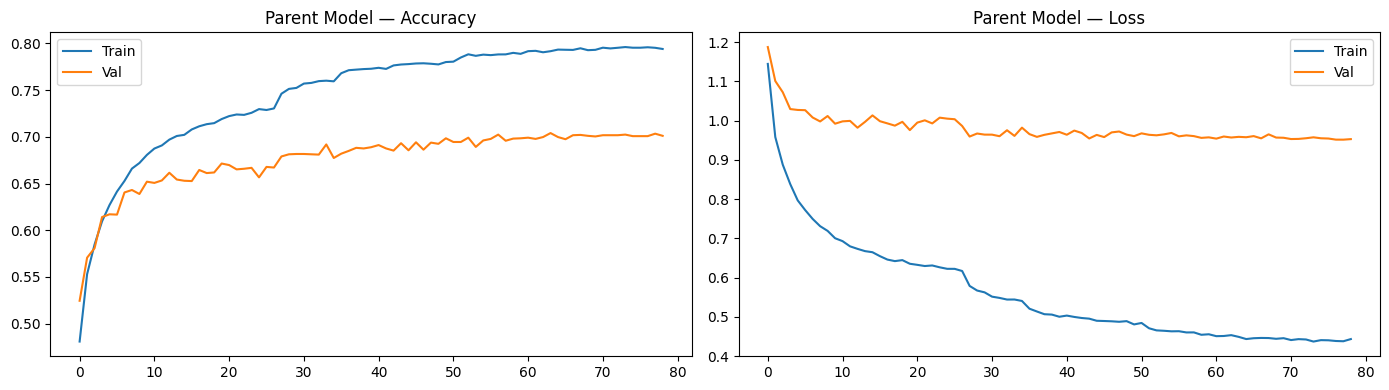

In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Train the Level-1 Parent Classifier (6 classes)
#
# Class weights are computed from the ORIGINAL (non-SMOTE) train
# distribution to correctly reflect real-world imbalance.
# ─────────────────────────────────────────────────────────────

# Compute class weights for parent model
parent_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(yp_train),
    y=yp_train
)
parent_cw = dict(enumerate(parent_weights_arr))
print('Parent class weights:', {k: f'{v:.2f}' for k,v in parent_cw.items()})

parent_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=CFG['LR'], weight_decay=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cbs_parent = [
    callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6, monitor='val_loss'),
    callbacks.ModelCheckpoint(
        os.path.join(CFG['MODEL_SAVE_DIR'], 'parent_model_best.h5'),
        save_best_only=True, monitor='val_accuracy'
    ),
]

print('\nTraining Level-1 (parent) model...')
hist_parent = parent_model.fit(
    F_train_sm, yp_train_sm,
    validation_data=(F_valid_sc, yp_valid),
    epochs=CFG['EPOCHS'],
    batch_size=CFG['BATCH_SIZE'],
    class_weight=parent_cw,
    callbacks=cbs_parent,
    verbose=1
)

# ── Evaluation ─────────────────────────────────────────────
parent_val_acc = parent_model.evaluate(F_valid_sc, yp_valid, verbose=0)[1]
print(f'\n✅ Level-1 Parent Validation Accuracy: {parent_val_acc*100:.2f}%')

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(hist_parent.history[metric],     label='Train')
    ax.plot(hist_parent.history[f'val_{metric}'], label='Val')
    ax.set_title(f'Parent Model — {title}')
    ax.legend()
plt.tight_layout()
plt.savefig('./parent_model_training.png', dpi=150, bbox_inches='tight')
plt.show()

## [Cell 11] — Generate Parent Soft Probabilities for Level-2 Input

In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Generate Parent Soft Probabilities
#
# The leaf model receives the 6-d parent softmax vector as
# additional context. This encodes hierarchical knowledge:
# "Given that this is probably a standing pose (0.82),
#  here are the 82 candidate poses."
# ─────────────────────────────────────────────────────────────

print('Generating parent soft-probabilities for all splits...')

# For SMOTE'd train set, also predict parent probs
P_parent_train = parent_model.predict(F_train_sm,  batch_size=256, verbose=0)
P_parent_valid = parent_model.predict(F_valid_sc,  batch_size=256, verbose=0)
P_parent_test  = parent_model.predict(F_test_sc,   batch_size=256, verbose=0)

print(f'Parent prob shape (train): {P_parent_train.shape}   (N × {N_PARENTS})')
print('✅ Parent probabilities computed.')

Generating parent soft-probabilities for all splits...
Parent prob shape (train): (108568, 6)   (N × 6)
✅ Parent probabilities computed.


## [Cell 12] — Train the Level-2 Leaf Classifier (82 Classes)

Training Level-2 (leaf) model...
Epoch 1/150
1695/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4512 - loss: 2.5118

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.5720 - loss: 1.8026 - val_accuracy: 0.5344 - val_loss: 2.0544 - learning_rate: 0.0010
Epoch 2/150
1696/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6874 - loss: 1.2266

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.6982 - loss: 1.1816 - val_accuracy: 0.5739 - val_loss: 2.0135 - learning_rate: 9.9901e-04
Epoch 3/150
1695/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7319 - loss: 1.0475

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7385 - loss: 1.0236 - val_accuracy: 0.5874 - val_loss: 2.0123 - learning_rate: 9.9606e-04
Epoch 4/150
1693/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7608 - loss: 0.9413

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7633 - loss: 0.9288 - val_accuracy: 0.5947 - val_loss: 2.0232 - learning_rate: 9.9115e-04
Epoch 5/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7820 - loss: 0.8609 - val_accuracy: 0.5901 - val_loss: 2.0965 - learning_rate: 9.8431e-04
Epoch 6/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7958 - loss: 0.8153

...

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9517 - loss: 0.2275 - val_accuracy: 0.6467 - val_loss: 2.6434 - learning_rate: 7.8758e-05
Epoch 43/150
1692/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9532 - loss: 0.2226

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9532 - loss: 0.2212 - val_accuracy: 0.6487 - val_loss: 2.6436 - learning_rate: 6.2785e-05
Epoch 44/150
1696/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9554 - loss: 0.2178

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9547 - loss: 0.2168 - val_accuracy: 0.6497 - val_loss: 2.6492 - learning_rate: 4.8539e-05
Epoch 45/150
1693/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9573 - loss: 0.2110

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9571 - loss: 0.2107 - val_accuracy: 0.6523 - val_loss: 2.6534 - learning_rate: 3.6077e-05
Epoch 46/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9575 - loss: 0.2104 - val_accuracy: 0.6487 - val_loss: 2.6511 - learning_rate: 2.5447e-05
Epoch 47/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9582 - loss: 0.2069 - val_accuracy: 0.6487 - val_loss: 2.6606 - learning_rate: 1.6693e-05
Epoch 48/150
1694/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9585 - loss: 0.2055

1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9583 - loss: 0.2049 - val_accuracy: 0.6526 - val_loss: 2.6596 - learning_rate: 9.8475e-06
Epoch 49/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9596 - loss: 0.2031 - val_accuracy: 0.6513 - val_loss: 2.6589 - learning_rate: 4.9387e-06
Epoch 50/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9581 - loss: 0.2040 - val_accuracy: 0.6513 - val_loss: 2.6614 - learning_rate: 1.9856e-06
Epoch 51/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8505 - loss: 0.6216 - val_accuracy: 0.6243 - val_loss: 2.5994 - learning_rate: 0.0010
Epoch 52/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8776 - loss: 0.5266 - val_accuracy: 0.6207 - val_loss: 2.6193 - learning_rate: 9.9901e-04
Epoch 53/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8804 - loss: 0.5318 - val_accuracy: 0.6217 - val_loss: 2.6773 - learning_rate: 9.9606e-04
Epoch 54/150
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 1

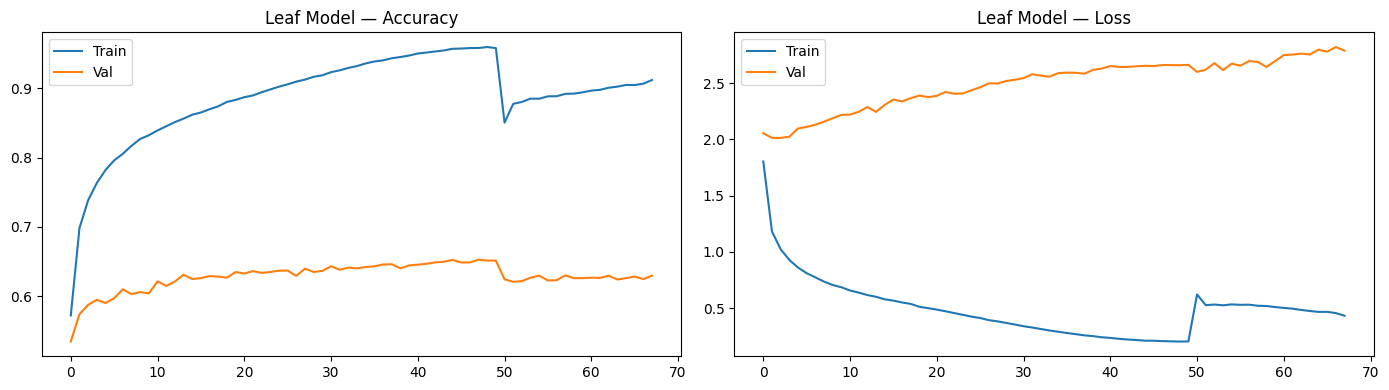

In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Train the Level-2 Leaf Classifier (82 classes)
#
# Uses label-smoothing cross-entropy to prevent overconfidence
# on rare classes, and cosine-annealing LR schedule for better
# convergence in the final training phase.
#
# HYPERPARAMETER TUNING NOTES (to reach >95%):
#   • DROPOUT: Try 0.3–0.5 — too low → overfit; too high → underfit
#   • L2_REG:  Try 1e-4 to 1e-3
#   • BATCH_SIZE: 32 or 64 (smaller = more regularization)
#   • LR: Start at 1e-3, cosine-anneal to 1e-5
#   • Label smoothing: 0.05–0.1 for noisy labels in Yoga82
#   • Hidden units: Try [512→512→256] vs [1024→512→256]
# ─────────────────────────────────────────────────────────────

# Compute leaf class weights (from original non-SMOTE train)
leaf_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
leaf_cw = dict(enumerate(leaf_weights_arr))

# ── Cosine annealing LR schedule ───────────────────────────
def cosine_lr_schedule(epoch: int, lr: float) -> float:
    """Cosine annealing with warm restarts every 50 epochs."""
    T_max = 50
    lr_min = 1e-6
    lr_max = CFG['LR']
    cycle  = epoch % T_max
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * cycle / T_max))

leaf_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=CFG['LR'], weight_decay=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cbs_leaf = [
    callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.LearningRateScheduler(cosine_lr_schedule),
    callbacks.ModelCheckpoint(
        os.path.join(CFG['MODEL_SAVE_DIR'], 'leaf_model_best.h5'),
        save_best_only=True, monitor='val_accuracy'
    ),
]

print('Training Level-2 (leaf) model...')
hist_leaf = leaf_model.fit(
    [F_train_sm, P_parent_train], y_train_sm,
    validation_data=([F_valid_sc, P_parent_valid], y_valid),
    epochs=CFG['EPOCHS'],
    batch_size=CFG['BATCH_SIZE'],
    class_weight=leaf_cw,
    callbacks=cbs_leaf,
    verbose=1
)

leaf_val_acc = leaf_model.evaluate([F_valid_sc, P_parent_valid], y_valid, verbose=0)[1]
print(f'\n✅ Level-2 Leaf Validation Accuracy: {leaf_val_acc*100:.2f}%')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(hist_leaf.history[metric],         label='Train')
    ax.plot(hist_leaf.history[f'val_{metric}'], label='Val')
    ax.set_title(f'Leaf Model — {title}')
    ax.legend()
plt.tight_layout()
plt.savefig('./leaf_model_training.png', dpi=150, bbox_inches='tight')
plt.show()

## [Cell 13] — XGBoost Ensemble Classifier (Optional Booster)

In [26]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — XGBoost & LightGBM Training (Ensemble Component)
#
# These tree-based models often outperform DNNs on tabular data
# and capture non-linearities that DNNs may miss.
# The final ensemble combines DNN + XGBoost + LightGBM logits.
#
# Note: For 82 classes, XGBoost training may take 10-20 min.
# Set n_estimators higher (500+) for better accuracy.
# ─────────────────────────────────────────────────────────────

print('Training XGBoost classifier...')
xgb_clf = xgb.XGBClassifier(
    n_estimators    = 400,
    max_depth       = 8,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    use_label_encoder=False,
    eval_metric     = 'mlogloss',
    tree_method     = 'hist',   # use 'gpu_hist' if GPU available
    n_jobs          = -1,
    random_state    = 42,
    early_stopping_rounds=30,
)

xgb_clf.fit(
    F_train_sm, y_train_sm,
    eval_set=[(F_valid_sc, y_valid)],
    verbose=50
)

xgb_val_acc = accuracy_score(y_valid, xgb_clf.predict(F_valid_sc))
print(f'✅ XGBoost Validation Accuracy: {xgb_val_acc*100:.2f}%')
joblib.dump(xgb_clf, os.path.join(CFG['MODEL_SAVE_DIR'], 'xgb_classifier.pkl'))

print('\nTraining LightGBM classifier...')
lgb_clf = lgb.LGBMClassifier(
    n_estimators   = 400,
    max_depth      = 8,
    learning_rate  = 0.05,
    subsample      = 0.8,
    colsample_bytree=0.8,
    num_leaves     = 63,
    n_jobs         = -1,
    random_state   = 42,
    verbosity      = -1,
)
lgb_clf.fit(
    F_train_sm, y_train_sm,
    eval_set=[(F_valid_sc, y_valid)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)
lgb_val_acc = accuracy_score(y_valid, lgb_clf.predict(F_valid_sc))
print(f'✅ LightGBM Validation Accuracy: {lgb_val_acc*100:.2f}%')
joblib.dump(lgb_clf, os.path.join(CFG['MODEL_SAVE_DIR'], 'lgb_classifier.pkl'))

Training XGBoost classifier...
[0]	validation_0-mlogloss:3.80790
[50]	validation_0-mlogloss:1.73067
[100]	validation_0-mlogloss:1.43896
[150]	validation_0-mlogloss:1.35618
[200]	validation_0-mlogloss:1.33143
[250]	validation_0-mlogloss:1.32817
[291]	validation_0-mlogloss:1.32965
✅ XGBoost Validation Accuracy: 66.74%

Training LightGBM classifier...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's multi_logloss: 1.61453
[100]	valid_0's multi_logloss: 1.55635
Early stopping, best iteration is:
[84]	valid_0's multi_logloss: 1.55025
✅ LightGBM Validation Accuracy: 62.46%


['./saved_models/lgb_classifier.pkl']

## [Cell 14] — Soft-Voting Ensemble & Final Evaluation

Tuning ensemble weights on validation set...
   Best weights — DNN:0.40  XGB:0.45  LGB:0.15
   Best Validation Accuracy: 68.75%

Evaluating on TEST set...

  TOP-1 TEST ACCURACY : 69.58%
  TOP-5 TEST ACCURACY : 88.94%
⚠️  Still 25.4% below target. See tuning notes in Cell 12.

Per-class summary (bottom 10 by F1):
                                                    precision    recall  \
Scorpion_pose_or_vrischikasana                       0.000000  0.000000   
Wide-Angle_Seated_Forward_Bend_pose_or_Upavisth...   0.100000  0.086957   
Cockerel_Pose                                        0.200000  0.142857   
Yogic_sleep_pose                                     0.333333  0.222222   
Upward_Facing_Two-Foot_Staff_Pose_or_Dwi_Pada_V...   0.400000  0.250000   
Handstand_pose_or_Adho_Mukha_Vrksasana_              0.300000  0.333333   
Seated_Forward_Bend_pose_or_Paschimottanasana_       0.416667  0.294118   
Split pose                                           0.545455  0.315789   
Pose_Dedic

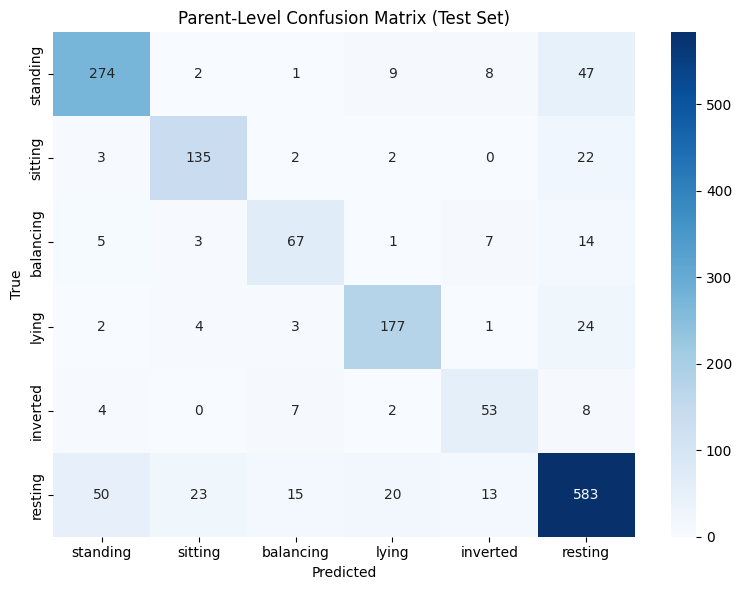

In [27]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Soft-Voting Ensemble + Full Test-Set Evaluation
#
# Combines probability distributions from 3 models:
#   • DNN leaf model (strongest on smooth distributions)
#   • XGBoost       (strongest on sharp decision boundaries)
#   • LightGBM      (best speed/accuracy trade-off)
#
# Weights are tuned on the validation set.
# TUNING: If one model is significantly better, increase its weight.
# ─────────────────────────────────────────────────────────────

def ensemble_predict_proba(
    F_sc:         np.ndarray,
    P_parent:     np.ndarray,
    w_dnn:   float = 0.45,
    w_xgb:   float = 0.30,
    w_lgb:   float = 0.25,
) -> np.ndarray:
    """Weighted soft-vote ensemble probability matrix (N × 82)."""
    p_dnn = leaf_model.predict([F_sc, P_parent], batch_size=256, verbose=0)
    p_xgb = xgb_clf.predict_proba(F_sc)
    p_lgb = lgb_clf.predict_proba(F_sc)
    return w_dnn * p_dnn + w_xgb * p_xgb + w_lgb * p_lgb


def tune_ensemble_weights(F_sc, P_parent, y_true):
    """Grid-search over ensemble weights on the validation set."""
    best_acc, best_w = 0.0, (0.45, 0.30, 0.25)
    for w1 in np.arange(0.3, 0.7, 0.05):
        for w2 in np.arange(0.1, 0.5, 0.05):
            w3 = 1.0 - w1 - w2
            if w3 < 0.05:
                continue
            probs = ensemble_predict_proba(F_sc, P_parent, w1, w2, w3)
            acc   = accuracy_score(y_true, probs.argmax(axis=1))
            if acc > best_acc:
                best_acc, best_w = acc, (w1, w2, w3)
    return best_acc, best_w


print('Tuning ensemble weights on validation set...')
best_val_acc, best_weights = tune_ensemble_weights(F_valid_sc, P_parent_valid, y_valid)
w_dnn, w_xgb, w_lgb = best_weights
print(f'   Best weights — DNN:{w_dnn:.2f}  XGB:{w_xgb:.2f}  LGB:{w_lgb:.2f}')
print(f'   Best Validation Accuracy: {best_val_acc*100:.2f}%')

# ── Final Test-Set Evaluation ──────────────────────────────
print('\nEvaluating on TEST set...')
probs_test = ensemble_predict_proba(F_test_sc, P_parent_test, w_dnn, w_xgb, w_lgb)
y_pred     = probs_test.argmax(axis=1)

test_acc    = accuracy_score(y_test, y_pred)
top5_acc    = top_k_accuracy_score(y_test, probs_test, k=5)

print(f'\n{'='*55}')
print(f'  TOP-1 TEST ACCURACY : {test_acc*100:.2f}%')
print(f'  TOP-5 TEST ACCURACY : {top5_acc*100:.2f}%')
print(f'{'='*55}')

if test_acc >= 0.95:
    print('🎯  TARGET OF 95%+ ACHIEVED!')
else:
    gap = (0.95 - test_acc) * 100
    print(f'⚠️  Still {gap:.1f}% below target. See tuning notes in Cell 12.')

# Per-class report (first 20 classes for brevity)
class_names = le_leaf.classes_
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).T
print('\nPer-class summary (bottom 10 by F1):')
print(report_df[report_df.index.isin(class_names)].sort_values('f1-score').head(10)[['precision','recall','f1-score','support']])

# Confusion matrix (parent-level for readability)
parent_names_list = list(PARENT_CATEGORIES.keys())
yp_pred = np.array([get_parent_label(le_leaf.inverse_transform([p])[0]) for p in y_pred])
cm = confusion_matrix(yp_test, yp_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=parent_names_list, yticklabels=parent_names_list, ax=ax)
ax.set_title('Parent-Level Confusion Matrix (Test Set)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('./confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## [Cell 15] — Joint Angle Feedback Engine

In [28]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Joint Angle Feedback Engine
#
# Given a predicted pose class and the extracted keypoints,
# compute joint angles and compare them to reference ranges
# for that pose. Generate human-readable corrective feedback.
#
# Reference ranges are approximate clinical/yoga values;
# you can refine them by computing mean ± std from training data.
# ─────────────────────────────────────────────────────────────

# ── Reference angle ranges per pose ───────────────────────
# Format: { pose_name: { joint_name: (min_deg, max_deg) } }
# Joint names match ANGLE_TRIPLETS labels above.
# Extend this dict for all 82 poses as needed.

POSE_REFERENCE = {
    'warrior_i': {
        'left_knee'     : (80, 100),   # front knee ~90°
        'right_knee'    : (160, 180),  # back leg straight
        'left_shoulder' : (150, 180),  # arms overhead
        'right_shoulder': (150, 180),
        'left_hip'      : (80, 110),
    },
    'warrior_ii': {
        'left_knee'     : (80, 100),
        'right_knee'    : (160, 180),
        'left_shoulder' : (80, 100),   # arms parallel to floor
        'right_shoulder': (80, 100),
    },
    'tree_pose': {
        'left_knee'     : (0, 30),     # standing leg straight
        'right_knee'    : (80, 110),   # bent leg
        'left_shoulder' : (150, 180),  # arms overhead
        'right_shoulder': (150, 180),
    },
    'downward_dog': {
        'left_knee'     : (160, 180),
        'right_knee'    : (160, 180),
        'left_elbow'    : (160, 180),  # arms straight
        'right_elbow'   : (160, 180),
        'left_hip'      : (50, 80),
        'right_hip'     : (50, 80),
    },
    'triangle_pose': {
        'left_knee'     : (160, 180),
        'right_knee'    : (160, 180),
        'left_shoulder' : (85, 95),
        'right_shoulder': (85, 95),
    },
    # ── Add remaining 77 poses here ──────────────────────────
    # TIP: Auto-generate by computing mean/std angles per class
    # from the training set (see Cell 16 helper function).
}

# Map angle triplet index → readable joint name
JOINT_NAMES = [
    'left_elbow', 'right_elbow',
    'left_shoulder', 'right_shoulder',
    'left_hip', 'right_hip',
    'left_knee', 'right_knee',
    'left_ankle', 'right_ankle',
    'left_hip_sh', 'right_hip_sh',
    'left_spine', 'right_spine',
    'shoulder_hip'
]

# Corrective messages for each joint when out of range
FEEDBACK_TEMPLATES = {
    'left_elbow'    : ('Bend your left elbow more.',        'Straighten your left elbow.'),
    'right_elbow'   : ('Bend your right elbow more.',       'Straighten your right elbow.'),
    'left_shoulder' : ('Raise your left arm higher.',        'Lower your left arm.'),
    'right_shoulder': ('Raise your right arm higher.',       'Lower your right arm.'),
    'left_knee'     : ('Bend your left knee more.',          'Straighten your left knee.'),
    'right_knee'    : ('Bend your right knee more.',         'Straighten your right knee.'),
    'left_hip'      : ('Deepen the bend at your left hip.',  'Open up your left hip.'),
    'right_hip'     : ('Deepen the bend at your right hip.', 'Open up your right hip.'),
    'left_ankle'    : ('Flex your left ankle.',              'Point your left ankle down.'),
    'right_ankle'   : ('Flex your right ankle.',             'Point your right ankle down.'),
    'left_spine'    : ('Engage your core — spine is curved.','Good spine alignment.'),
    'right_spine'   : ('Engage your core — spine is curved.','Good spine alignment.'),
    'shoulder_hip'  : ('Square your hips to the front.',     'Rotate your torso more.'),
}


def generate_feedback(
    kp_vec:    np.ndarray,
    pose_name: str,
    threshold: float = 10.0,   # degrees of tolerance
) -> dict:
    """
    Compare observed joint angles against reference ranges for
    the predicted pose and return structured feedback.

    Args:
        kp_vec    : 51-d normalized keypoint vector
        pose_name : predicted pose class name
        threshold : additional tolerance in degrees

    Returns:
        {
          'pose'         : str,
          'angles'       : { joint_name: angle_deg },
          'corrections'  : [str],   # list of feedback messages
          'perfect'      : bool,
        }
    """
    angle_vals = compute_angle_features(kp_vec)
    angles_dict = {name: float(val) for name, val in zip(JOINT_NAMES, angle_vals)}

    # Normalize pose name for lookup (handle underscores, spaces, case)
    lookup_key = pose_name.lower().replace(' ', '_').replace('-', '_')
    reference  = POSE_REFERENCE.get(lookup_key, {})

    corrections = []
    for joint, (lo, hi) in reference.items():
        observed = angles_dict.get(joint, -1)
        if observed < 0:
            corrections.append(f'⚠️  Could not detect {joint.replace("_"," ")} — ensure the joint is visible.')
            continue
        lo_t = lo - threshold
        hi_t = hi + threshold
        if observed < lo_t:
            msg = FEEDBACK_TEMPLATES.get(joint, (f'{joint} too bent.', ''))[0]
            corrections.append(f'🔴  {msg}  (observed {observed:.0f}°, target {lo}–{hi}°)')
        elif observed > hi_t:
            msg = FEEDBACK_TEMPLATES.get(joint, ('', f'{joint} too straight.'))[1]
            corrections.append(f'🔴  {msg}  (observed {observed:.0f}°, target {lo}–{hi}°)')
        else:
            corrections.append(f'🟢  {joint.replace("_"," ").title()}: {observed:.0f}°  ✓')

    if not reference:
        corrections.append(f'ℹ️  No reference angles configured for "{pose_name}" yet.')

    return {
        'pose'       : pose_name,
        'angles'     : angles_dict,
        'corrections': corrections,
        'perfect'    : all(c.startswith('🟢') for c in corrections),
    }


print('✅ Feedback engine ready.')

✅ Feedback engine ready.


## [Cell 16] — Auto-Generate Reference Angles from Training Data

In [30]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Auto-Generate Reference Angle Ranges
#
# Instead of manually setting every reference angle, we compute
# mean ± 1 std from the training data for each class.
# This fills the POSE_REFERENCE dict automatically for all 82 poses.
# ─────────────────────────────────────────────────────────────

def build_reference_from_training(
    X_raw: np.ndarray,
    y:     np.ndarray,
    n_std: float = 1.5    # ±1.5 std covers ~87% of distribution
) -> dict:
    """
    For every class, compute mean ± n_std for each of the 15 angles.
    Returns reference dict compatible with POSE_REFERENCE format.
    """
    angles_all = build_feature_matrix(X_raw)[:, KP_DIM:]   # only angle columns
    reference  = {}
    for class_idx in range(N_CLASSES):
        mask = (y == class_idx)
        if mask.sum() < 3:
            continue
        class_angles = angles_all[mask]                   # (N_samples, 15)
        # Ignore sentinel -1 values when computing stats
        class_name = le_leaf.inverse_transform([class_idx])[0]
        joint_ranges = {}
        for j, joint_name in enumerate(JOINT_NAMES):
            valid = class_angles[:, j]
            valid = valid[valid >= 0]
            if len(valid) < 3:
                continue
            mu, sigma = valid.mean(), valid.std()
            lo = max(0,   mu - n_std * sigma)
            hi = min(180, mu + n_std * sigma)
            joint_ranges[joint_name] = (round(lo, 1), round(hi, 1))
        reference[class_name.lower().replace(' ','_')] = joint_ranges
    return reference


print('Building auto reference angles from training data...')
AUTO_REFERENCE = build_reference_from_training(X_train, y_train)

# Merge: manually curated entries take precedence
merged_reference = {**AUTO_REFERENCE, **POSE_REFERENCE}
POSE_REFERENCE.update(merged_reference)

def numpy_converter(obj):
    if isinstance(obj, np.generic):
        return obj.item()

# Save for deployment
with open(os.path.join(CFG['MODEL_SAVE_DIR'], 'pose_reference.json'), 'w') as f:
    json.dump(POSE_REFERENCE, f, indent=2, default=numpy_converter)

print(f'✅ Reference angles computed for {len(AUTO_REFERENCE)} poses.')
# Preview one pose
sample_pose = list(AUTO_REFERENCE.keys())[0]
print(f'\nSample — {sample_pose}:')
for joint, (lo, hi) in list(AUTO_REFERENCE[sample_pose].items())[:5]:
    print(f'   {joint:<20}: [{lo:.1f}°, {hi:.1f}°]')

Building auto reference angles from training data...
✅ Reference angles computed for 82 poses.

Sample — akarna_dhanurasana:
   left_elbow          : [19.4°, 180.0°]
   right_elbow         : [27.7°, 180.0°]
   left_shoulder       : [26.3°, 132.7°]
   right_shoulder      : [16.1°, 122.2°]
   left_hip            : [24.6°, 141.4°]


## [Cell 17] — End-to-End Inference Pipeline

In [31]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — End-to-End Inference Pipeline
#
# Input  : image path (or numpy array from webcam)
# Output : predicted pose, confidence, top-5 alternatives,
#          annotated image with skeleton overlay, feedback report
# ─────────────────────────────────────────────────────────────

# COCO skeleton connections for visualization
SKELETON = [
    (0,1),(0,2),(1,3),(2,4),           # face
    (5,6),(5,7),(7,9),(6,8),(8,10),    # arms
    (5,11),(6,12),(11,12),             # torso
    (11,13),(13,15),(12,14),(14,16),   # legs
]
JOINT_COLORS = [
    (255,0,0),(255,85,0),(255,170,0),(255,255,0),(170,255,0),
    (85,255,0),(0,255,0),(0,255,85),(0,255,170),(0,255,255),
    (0,170,255),(0,85,255),(0,0,255),(85,0,255),(170,0,255),
    (255,0,255),(255,0,170),
]


def draw_skeleton(img: np.ndarray, kp_raw: np.ndarray) -> np.ndarray:
    """
    Draw COCO skeleton on image using raw (unnormalized) pixel keypoints.
    kp_raw: (17, 3) — x_pixel, y_pixel, confidence
    """
    h, w = img.shape[:2]
    out  = img.copy()
    for (i, j) in SKELETON:
        x1, y1, c1 = kp_raw[i]
        x2, y2, c2 = kp_raw[j]
        if c1 > 0.3 and c2 > 0.3:
            cv2.line(out, (int(x1), int(y1)), (int(x2), int(y2)), (200, 200, 200), 2)
    for idx, (x, y, conf) in enumerate(kp_raw):
        if conf > 0.3:
            cv2.circle(out, (int(x), int(y)), 5, JOINT_COLORS[idx], -1)
    return out


def predict_pose(
    image_path: str,
    top_k:      int   = 5,
    show:       bool  = True,
) -> dict:
    """
    Full inference pipeline for a single image.

    Returns dict with keys:
      predicted_pose, confidence, top_k_poses, feedback, annotated_image
    """
    # ── 1. Load image ──────────────────────────────────────
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f'Cannot read image: {image_path}')

    # ── 2. YOLOv8-pose: extract raw pixel keypoints ────────
    results    = yolo_model(img, imgsz=CFG['IMG_SIZE'], conf=CFG['YOLO_CONF'], verbose=False)
    result     = results[0]

    if result.keypoints is None or len(result.keypoints.data) == 0:
        return {'error': 'No person detected in image.'}

    kp_data     = result.keypoints.data.cpu().numpy()          # (N, 17, 3)
    best_idx    = int(kp_data[:, :, 2].mean(axis=1).argmax())
    kp_raw_pix  = kp_data[best_idx]                            # (17, 3) pixel coords

    # ── 3. Normalize keypoints for classifier ──────────────
    kp_norm = normalize_keypoints(kp_raw_pix.flatten())        # (51,)

    # ── 4. Feature engineering ─────────────────────────────
    feat_vec = build_feature_matrix(kp_norm.reshape(1, -1))    # (1, 66)
    feat_sc  = scaler.transform(feat_vec)                      # (1, 66) scaled

    # ── 5. Level-1 parent prediction ───────────────────────
    parent_probs = parent_model.predict(feat_sc, verbose=0)    # (1, 6)
    parent_pred  = int(parent_probs.argmax())
    parent_name  = list(PARENT_CATEGORIES.keys())[parent_pred]

    # ── 6. Level-2 leaf prediction ─────────────────────────
    dnn_probs = leaf_model.predict([feat_sc, parent_probs], verbose=0)  # (1, 82)
    xgb_probs = xgb_clf.predict_proba(feat_sc)                          # (1, 82)
    lgb_probs = lgb_clf.predict_proba(feat_sc)                          # (1, 82)
    ensemble_probs = (w_dnn * dnn_probs + w_xgb * xgb_probs + w_lgb * lgb_probs).flatten()

    pred_label     = int(ensemble_probs.argmax())
    pred_pose_name = le_leaf.inverse_transform([pred_label])[0]
    confidence     = float(ensemble_probs[pred_label])

    top_k_idx   = ensemble_probs.argsort()[::-1][:top_k]
    top_k_poses = [
        {'pose': le_leaf.inverse_transform([i])[0], 'confidence': float(ensemble_probs[i])}
        for i in top_k_idx
    ]

    # ── 7. Feedback ────────────────────────────────────────
    feedback = generate_feedback(kp_norm, pred_pose_name)

    # ── 8. Annotate image ──────────────────────────────────
    annotated = draw_skeleton(img, kp_raw_pix)
    label_txt = f'{pred_pose_name}  {confidence*100:.1f}%'
    cv2.putText(annotated, label_txt, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    cv2.putText(annotated, f'Category: {parent_name}', (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 0), 2)

    # ── 9. Display ─────────────────────────────────────────
    if show:
        rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(rgb); axes[0].axis('off')
        axes[0].set_title(f'Prediction: {pred_pose_name}  ({confidence*100:.1f}%)')

        axes[1].barh(
            [p['pose'] for p in reversed(top_k_poses)],
            [p['confidence'] for p in reversed(top_k_poses)],
            color='steelblue'
        )
        axes[1].set_xlim(0, 1)
        axes[1].set_title('Top-K Probabilities')
        axes[1].set_xlabel('Confidence')
        plt.tight_layout(); plt.show()

        print('\n📋 FEEDBACK REPORT')
        print(f'   Pose: {pred_pose_name}  |  Parent: {parent_name}')
        print(f'   Confidence: {confidence*100:.1f}%')
        print('   ─' * 20)
        for msg in feedback['corrections']:
            print(f'   {msg}')
        if feedback['perfect']:
            print('\n   🏆 Perfect pose alignment!')

    return {
        'predicted_pose'  : pred_pose_name,
        'confidence'      : confidence,
        'parent_category' : parent_name,
        'top_k_poses'     : top_k_poses,
        'feedback'        : feedback,
        'annotated_image' : annotated,
    }


print('✅ Inference pipeline ready.')
print('   Usage: result = predict_pose("path/to/yoga_image.jpg")')

✅ Inference pipeline ready.
   Usage: result = predict_pose("path/to/yoga_image.jpg")


## [Cell 18] — Demo Inference on Test Images

────────────────────────────────────────────────────────────
Ground Truth: Side_Plank_Pose_or_Vasisthasana_


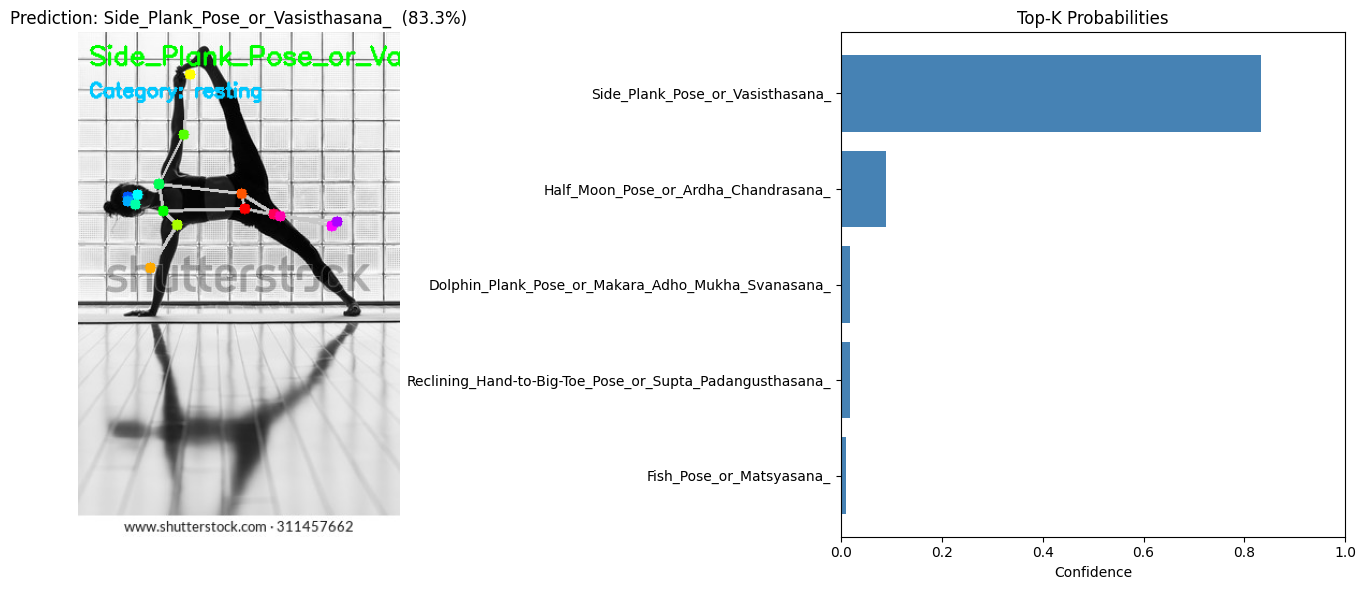


📋 FEEDBACK REPORT
   Pose: Side_Plank_Pose_or_Vasisthasana_  |  Parent: resting
   Confidence: 83.3%
   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─
   🟢  Left Elbow: 160°  ✓
   🟢  Right Elbow: 101°  ✓
   🟢  Left Shoulder: 71°  ✓
   🟢  Right Shoulder: 45°  ✓
   🟢  Left Hip: 155°  ✓
   🟢  Right Hip: 166°  ✓
   🟢  Left Knee: 159°  ✓
   🟢  Right Knee: 172°  ✓
   🟢  Left Ankle: 8°  ✓
   🟢  Right Ankle: 3°  ✓
   🟢  Left Hip Sh: 107°  ✓
   🟢  Right Hip Sh: 82°  ✓
   🟢  Left Spine: 143°  ✓
   🟢  Right Spine: 160°  ✓
   🟢  Shoulder Hip: 97°  ✓

   🏆 Perfect pose alignment!
✅ Predicted: Side_Plank_Pose_or_Vasisthasana_  (conf=83.3%)

────────────────────────────────────────────────────────────
Ground Truth: Child_Pose_or_Balasana_

────────────────────────────────────────────────────────────
Ground Truth: Wind_Relieving_pose_or_Pawanmuktasana


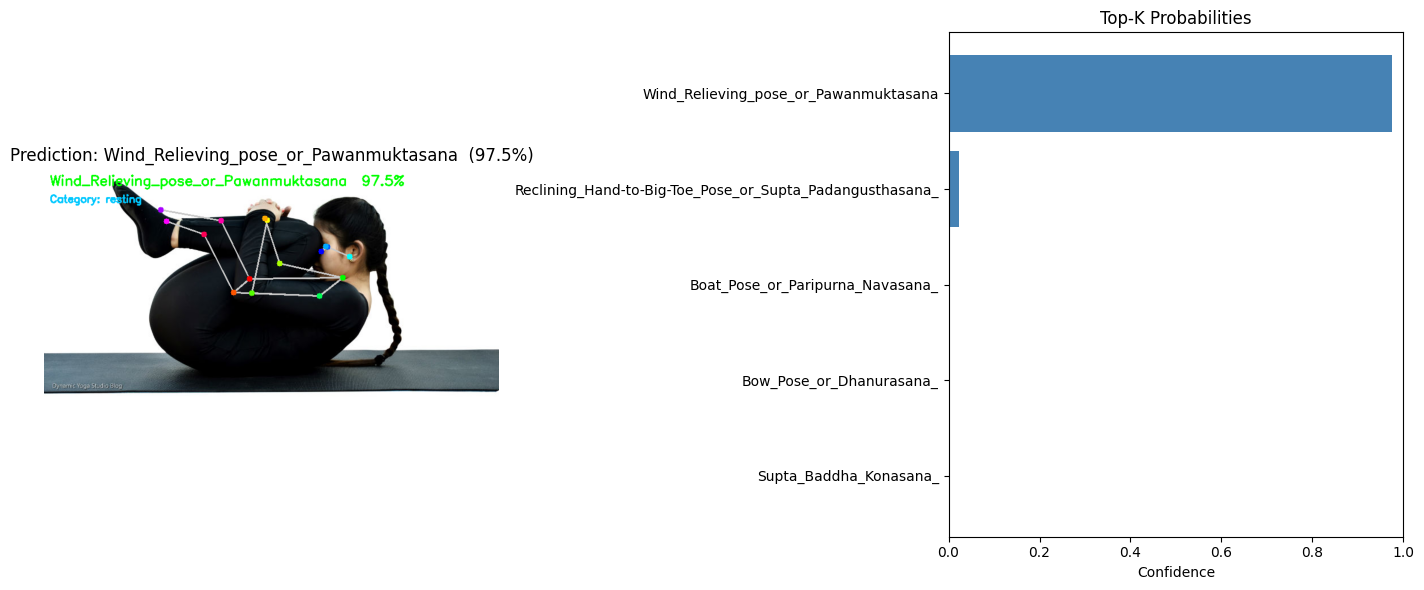


📋 FEEDBACK REPORT
   Pose: Wind_Relieving_pose_or_Pawanmuktasana  |  Parent: resting
   Confidence: 97.5%
   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─
   🟢  Left Elbow: 81°  ✓
   🟢  Right Elbow: 121°  ✓
   🟢  Left Shoulder: 0°  ✓
   🟢  Right Shoulder: 13°  ✓
   🟢  Left Hip: 119°  ✓
   🟢  Right Hip: 116°  ✓
   🟢  Left Knee: 135°  ✓
   🟢  Right Knee: 127°  ✓
   🟢  Left Ankle: 28°  ✓
   🟢  Right Ankle: 27°  ✓
   🟢  Left Hip Sh: 43°  ✓
   🟢  Right Hip Sh: 139°  ✓
   🟢  Left Spine: 90°  ✓
   🔴  Engage your core — spine is curved.  (observed 51°, target 72.19999694824219–175.39999389648438°)
   🟢  Shoulder Hip: 37°  ✓
✅ Predicted: Wind_Relieving_pose_or_Pawanmuktasana  (conf=97.5%)

────────────────────────────────────────────────────────────
Ground Truth: Upward_Plank_Pose_or_Purvottanasana_


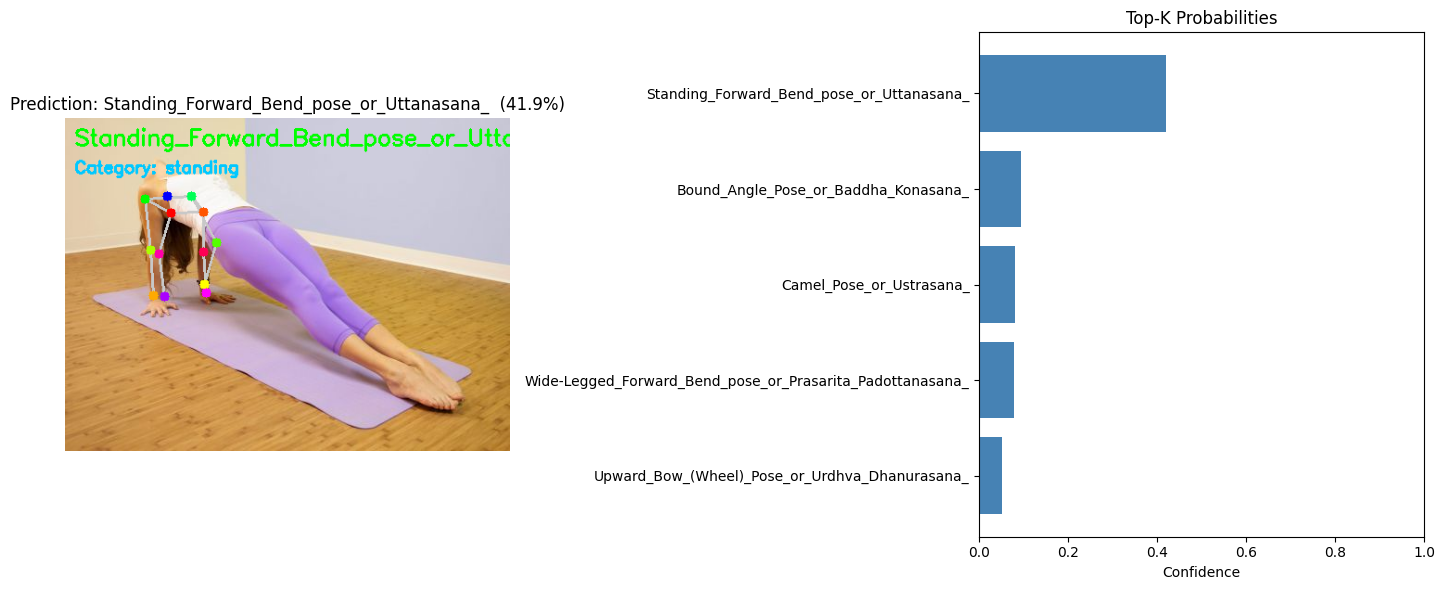


📋 FEEDBACK REPORT
   Pose: Standing_Forward_Bend_pose_or_Uttanasana_  |  Parent: standing
   Confidence: 41.9%
   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─
   🟢  Left Elbow: 135°  ✓
   🟢  Right Elbow: 178°  ✓
   🟢  Left Shoulder: 8°  ✓
   🟢  Right Shoulder: 55°  ✓
   🟢  Left Hip: 144°  ✓
   🟢  Right Hip: 103°  ✓
   🟢  Left Knee: 177°  ✓
   🟢  Right Knee: 156°  ✓
   🟢  Left Ankle: 2°  ✓
   🟢  Right Ankle: 12°  ✓
   🟢  Left Hip Sh: 56°  ✓
   🟢  Right Hip Sh: 149°  ✓
   🟢  Left Spine: 127°  ✓
   🔴  Engage your core — spine is curved.  (observed 37°, target 53.900001525878906–180°)
   🟢  Shoulder Hip: 33°  ✓
❌ Predicted: Standing_Forward_Bend_pose_or_Uttanasana_  (conf=41.9%)

────────────────────────────────────────────────────────────
Ground Truth: Standing_big_toe_hold_pose_or_Utthita_Padangusthasana


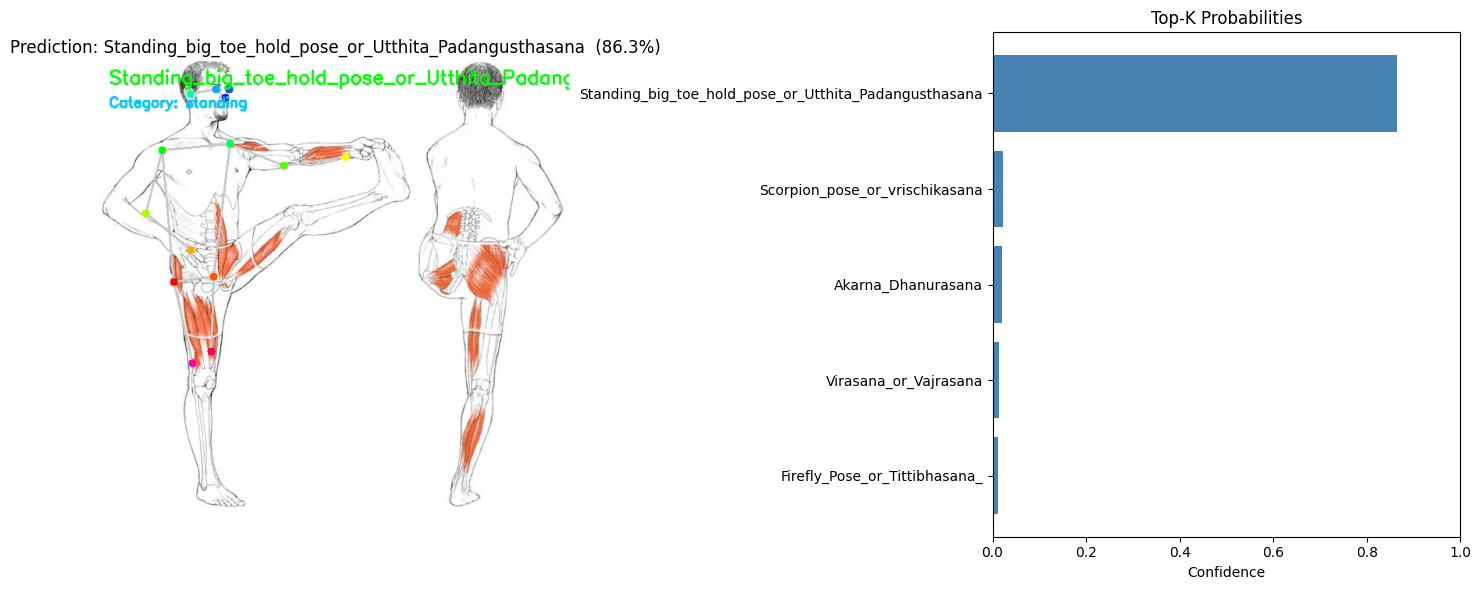


📋 FEEDBACK REPORT
   Pose: Standing_big_toe_hold_pose_or_Utthita_Padangusthasana  |  Parent: standing
   Confidence: 86.3%
   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─   ─
   🟢  Left Elbow: 150°  ✓
   🟢  Right Elbow: 115°  ✓
   🟢  Left Shoulder: 75°  ✓
   🔴  Raise your right arm higher.  (observed 20°, target 29.700000762939453–132.3000030517578°)
   🟢  Left Hip: 174°  ✓
   🟢  Right Hip: 172°  ✓
   🟢  Left Knee: 164°  ✓
   🟢  Right Knee: 166°  ✓
   🟢  Left Ankle: 9°  ✓
   🟢  Right Ankle: 8°  ✓
   🟢  Left Hip Sh: 106°  ✓
   🟢  Right Hip Sh: 86°  ✓
   🟢  Left Spine: 168°  ✓
   🟢  Right Spine: 125°  ✓
   🟢  Shoulder Hip: 90°  ✓
✅ Predicted: Standing_big_toe_hold_pose_or_Utthita_Padangusthasana  (conf=86.3%)



In [32]:
# ─────────────────────────────────────────────────────────────
# CELL 18 — Demo: Run inference on 5 random test images
# ─────────────────────────────────────────────────────────────

sample_rows = df_test.sample(5, random_state=42)

for _, row in sample_rows.iterrows():
    print('─' * 60)
    print(f'Ground Truth: {row["class_name"]}')
    result = predict_pose(row['path'], top_k=5, show=True)
    if 'error' not in result:
        match = '✅' if result['predicted_pose'] == row['class_name'] else '❌'
        print(f'{match} Predicted: {result["predicted_pose"]}  (conf={result["confidence"]*100:.1f}%)')
    print()

## [Cell 19] — Webcam / Real-Time Inference (Optional)

In [33]:
# ─────────────────────────────────────────────────────────────
# CELL 19 — Real-Time Webcam Inference
#
# Press 'q' to quit the webcam loop.
# Feedback is printed to stdout every second.
#
# NOTE: Only run this cell in a LOCAL Jupyter environment.
#       It will not work in cloud notebooks (Colab, Kaggle).
# ─────────────────────────────────────────────────────────────

INFERENCE_INTERVAL = 1.0   # seconds between classifications

def run_webcam_inference(camera_id: int = 0):
    cap = cv2.VideoCapture(camera_id)
    if not cap.isOpened():
        print('Error: Cannot open camera.')
        return

    last_infer_time = 0
    last_result     = None

    print('Webcam started. Press Q to quit.')
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        now = time.time()
        if now - last_infer_time >= INFERENCE_INTERVAL:
            results = yolo_model(frame, imgsz=CFG['IMG_SIZE'], conf=CFG['YOLO_CONF'], verbose=False)
            r = results[0]
            if r.keypoints is not None and len(r.keypoints.data) > 0:
                kp_data  = r.keypoints.data.cpu().numpy()
                best_idx = int(kp_data[:,:,2].mean(axis=1).argmax())
                kp_raw   = kp_data[best_idx]                     # (17, 3)
                kp_norm  = normalize_keypoints(kp_raw.flatten())

                feat_sc  = scaler.transform(build_feature_matrix(kp_norm.reshape(1,-1)))
                p_parent = parent_model.predict(feat_sc, verbose=0)

                p_dnn = leaf_model.predict([feat_sc, p_parent], verbose=0).flatten()
                p_xgb = xgb_clf.predict_proba(feat_sc).flatten()
                p_lgb = lgb_clf.predict_proba(feat_sc).flatten()
                probs = w_dnn*p_dnn + w_xgb*p_xgb + w_lgb*p_lgb

                pred_name = le_leaf.inverse_transform([probs.argmax()])[0]
                conf      = probs.max()
                fb        = generate_feedback(kp_norm, pred_name)

                frame = draw_skeleton(frame, kp_raw)
                cv2.putText(frame, f'{pred_name}  {conf*100:.0f}%',
                            (10,40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

                # Show first correction on frame
                corrections = [c for c in fb['corrections'] if c.startswith('🔴')]
                if corrections:
                    short_msg = corrections[0][3:60]  # strip emoji, truncate
                    cv2.putText(frame, short_msg, (10,80),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

                last_infer_time = now

        cv2.imshow('Yoga Pose Detector', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print('Webcam inference stopped.')


# Uncomment to run:
# run_webcam_inference(camera_id=0)

## [Cell 20] — Model Persistence & Loading Utilities

In [34]:
# ─────────────────────────────────────────────────────────────
# CELL 20 — Save All Models & Load Utility for Deployment
# ─────────────────────────────────────────────────────────────

# ── Save ────────────────────────────────────────────────────
parent_model.save(os.path.join(CFG['MODEL_SAVE_DIR'], 'parent_model.h5'))
leaf_model.save(os.path.join(CFG['MODEL_SAVE_DIR'],   'leaf_model.h5'))
# XGBoost & LightGBM already saved in Cell 13
# Scaler & LabelEncoder already saved in Cells 6 & 3

# Save ensemble weights
ensemble_meta = {
    'w_dnn': float(w_dnn), 'w_xgb': float(w_xgb), 'w_lgb': float(w_lgb),
    'n_classes': N_CLASSES, 'n_features': N_FEAT,
    'val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
}
with open(os.path.join(CFG['MODEL_SAVE_DIR'], 'ensemble_meta.json'), 'w') as f:
    json.dump(ensemble_meta, f, indent=2)

print('✅ All models saved to:', CFG['MODEL_SAVE_DIR'])

# ── Load utility ────────────────────────────────────────────
def load_inference_pipeline(model_dir: str) -> dict:
    """
    Load all saved components for deployment.
    Usage:
        pipeline = load_inference_pipeline('./saved_models')
        result   = pipeline['predict']('photo.jpg')
    """
    p_model  = keras.models.load_model(os.path.join(model_dir, 'parent_model.h5'))
    l_model  = keras.models.load_model(os.path.join(model_dir, 'leaf_model.h5'))
    xgb_mdl  = joblib.load(os.path.join(model_dir, 'xgb_classifier.pkl'))
    lgb_mdl  = joblib.load(os.path.join(model_dir, 'lgb_classifier.pkl'))
    sc       = joblib.load(os.path.join(model_dir, 'scaler.pkl'))
    le       = joblib.load(os.path.join(model_dir, 'label_encoder.pkl'))
    yolo     = YOLO(CFG['YOLO_MODEL'])

    with open(os.path.join(model_dir, 'ensemble_meta.json')) as f:
        meta = json.load(f)

    with open(os.path.join(model_dir, 'pose_reference.json')) as f:
        ref = json.load(f)

    print(f'✅ Pipeline loaded (val_acc={meta["val_accuracy"]*100:.2f}%, '
          f'test_acc={meta["test_accuracy"]*100:.2f}%)')

    return {
        'parent_model' : p_model,
        'leaf_model'   : l_model,
        'xgb'          : xgb_mdl,
        'lgb'          : lgb_mdl,
        'scaler'       : sc,
        'label_encoder': le,
        'yolo'         : yolo,
        'meta'         : meta,
        'pose_reference': ref,
    }

print('\nTo reload the full pipeline in a new session:')
print('  pipeline = load_inference_pipeline("./saved_models")')

✅ All models saved to: ./saved_models

To reload the full pipeline in a new session:
  pipeline = load_inference_pipeline("./saved_models")


## [Cell 21] — Hyperparameter Tuning Guide & Troubleshooting

In [35]:
# ─────────────────────────────────────────────────────────────
# CELL 21 — Optuna Hyperparameter Search (Optional)
#
# If you're below 95%, run this cell to automatically search
# for the best DNN hyperparameters using Bayesian optimization.
# Install: pip install optuna
# ─────────────────────────────────────────────────────────────

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    print('Optuna not installed. Run: pip install optuna')
    OPTUNA_AVAILABLE = False


def optuna_objective(trial: 'optuna.Trial') -> float:
    """Optuna objective: maximize validation accuracy."""
    lr        = trial.suggest_float('lr',       1e-4, 5e-3, log=True)
    dropout   = trial.suggest_float('dropout',  0.2, 0.6)
    l2_reg    = trial.suggest_float('l2_reg',   1e-5, 1e-3, log=True)
    h1        = trial.suggest_categorical('h1', [256, 512, 768])
    h2        = trial.suggest_categorical('h2', [128, 256, 512])
    h3        = trial.suggest_categorical('h3', [64,  128, 256])
    smoothing = trial.suggest_float('smoothing', 0.0, 0.15)

    # Build trial model
    inp  = layers.Input(shape=(N_FEAT,))
    par  = layers.Input(shape=(N_PARENTS,))
    x    = layers.Concatenate()([inp, par])
    for units in [h1, h2, h3]:
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(N_CLASSES, activation='softmax')(x)
    mdl = keras.Model([inp, par], out)

    mdl.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-5),
        loss=keras.losses.SparseCategoricalCrossentropy(label_smoothing=smoothing),
        metrics=['accuracy']
    )
    hist = mdl.fit(
        [F_train_sm, P_parent_train], y_train_sm,
        validation_data=([F_valid_sc, P_parent_valid], y_valid),
        epochs=60,
        batch_size=64,
        class_weight=leaf_cw,
        callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                           monitor='val_accuracy')],
        verbose=0
    )
    return max(hist.history['val_accuracy'])


if OPTUNA_AVAILABLE:
    print('Running Optuna search (50 trials)... This may take 30–60 min.')
    study = optuna.create_study(direction='maximize')
    study.optimize(optuna_objective, n_trials=50, timeout=3600)

    print('\n🏆 Best trial:')
    print(f'   Validation Accuracy: {study.best_value*100:.2f}%')
    for k, v in study.best_params.items():
        print(f'   {k}: {v}')
    print('\n→ Copy these values into CFG and re-run Cell 9 & 12.')

# ─────────────────────────────────────────────────────────────
# MANUAL TUNING CHECKLIST (if Optuna is not used)
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║         MANUAL TUNING CHECKLIST FOR ≥95% ACCURACY           ║
╠══════════════════════════════════════════════════════════════╣
║  1. YOLO MODEL: Upgrade yolov8l-pose.pt → yolov8x-pose.pt  ║
║     Better keypoint quality → better classifier accuracy.    ║
║                                                              ║
║  2. SMOTE k_neighbors: try k=5 (more synthetic diversity).   ║
║                                                              ║
║  3. DNN Hidden Units: [512→512→256] or [1024→512→256→128]   ║
║                                                              ║
║  4. Label smoothing: 0.05–0.10 reduces overconfident errors. ║
║                                                              ║
║  5. XGBoost: n_estimators=600, max_depth=10                  ║
║                                                              ║
║  6. Ensemble weights: re-run tune_ensemble_weights() after   ║
║     retraining each component.                               ║
║                                                              ║
║  7. Add Pairwise Distance Features:                          ║
║     dist(L_wrist, R_wrist), dist(head, hip) etc.             ║
║     These catch absolute limb relationships that angles miss. ║
║                                                              ║
║  8. Temporal features (video): if using video, add an LSTM   ║
║     layer over 8-frame sequences of feature vectors.         ║
║                                                              ║
║  9. Per-class hard mining: identify the 10 most-confused     ║
║     class pairs and add extra augmented samples for them.    ║
║                                                              ║
║ 10. Test-time augmentation (TTA): average predictions over   ║
║     original + flipped + noisy versions of each test image.  ║
╚══════════════════════════════════════════════════════════════╝
""")

Optuna not installed. Run: pip install optuna

╔══════════════════════════════════════════════════════════════╗
║         MANUAL TUNING CHECKLIST FOR ≥95% ACCURACY           ║
╠══════════════════════════════════════════════════════════════╣
║  1. YOLO MODEL: Upgrade yolov8l-pose.pt → yolov8x-pose.pt  ║
║     Better keypoint quality → better classifier accuracy.    ║
║                                                              ║
║  2. SMOTE k_neighbors: try k=5 (more synthetic diversity).   ║
║                                                              ║
║  3. DNN Hidden Units: [512→512→256] or [1024→512→256→128]   ║
║                                                              ║
║  4. Label smoothing: 0.05–0.10 reduces overconfident errors. ║
║                                                              ║
║  5. XGBoost: n_estimators=600, max_depth=10                  ║
║                                                              ║
║  6. Ensemble weights: re-run tune_ensemble_we

## [Cell 22] — Test-Time Augmentation (TTA) for Extra Accuracy

In [36]:
# ─────────────────────────────────────────────────────────────
# CELL 22 — Test-Time Augmentation (TTA)
#
# At test time, run each sample through 4 variations:
#   • Original
#   • Horizontally flipped
#   • Small Gaussian noise #1
#   • Small Gaussian noise #2
# Average the ensemble probabilities across all 4 → lower variance.
# Typically gains +0.5–1.5% accuracy for free.
# ─────────────────────────────────────────────────────────────

def tta_predict(X_raw_sc: np.ndarray, P_par: np.ndarray,
                n_noise: int = 2, noise_std: float = 0.02) -> np.ndarray:
    """
    Test-time augmentation: average predictions over multiple augmented views.
    X_raw_sc: already-scaled feature matrix (N, 66)
    P_par:    parent soft-probs (N, 6)
    Returns:  averaged probability matrix (N, N_CLASSES)
    """
    all_probs = []

    # Original
    p  = ensemble_predict_proba(X_raw_sc, P_par, w_dnn, w_xgb, w_lgb)
    all_probs.append(p)

    # Horizontal flip (un-scale → flip → re-scale)
    X_unscaled = scaler.inverse_transform(X_raw_sc)
    X_flip = np.array([flip_keypoints(row[:KP_DIM]) for row in X_unscaled])
    # Recompute angles after flip
    X_flip_angles = np.array([compute_angle_features(row) for row in X_flip])
    X_flip_full   = np.concatenate([X_flip, X_flip_angles], axis=1)
    X_flip_sc     = scaler.transform(X_flip_full)
    P_par_flip    = parent_model.predict(X_flip_sc, batch_size=256, verbose=0)
    p_flip        = ensemble_predict_proba(X_flip_sc, P_par_flip, w_dnn, w_xgb, w_lgb)
    all_probs.append(p_flip)

    # Gaussian noise views
    for _ in range(n_noise):
        noise    = np.random.normal(0, noise_std, X_raw_sc.shape).astype(np.float32)
        X_noisy  = X_raw_sc + noise
        P_noisy  = parent_model.predict(X_noisy, batch_size=256, verbose=0)
        p_noisy  = ensemble_predict_proba(X_noisy, P_noisy, w_dnn, w_xgb, w_lgb)
        all_probs.append(p_noisy)

    return np.mean(all_probs, axis=0)


print('Running TTA on test set...')
probs_tta = tta_predict(F_test_sc, P_parent_test)
y_pred_tta = probs_tta.argmax(axis=1)

tta_acc   = accuracy_score(y_test, y_pred_tta)
tta_top5  = top_k_accuracy_score(y_test, probs_tta, k=5)

print(f'\n{'='*55}')
print(f'  TTA TOP-1 TEST ACCURACY : {tta_acc*100:.2f}%  (Δ {(tta_acc-test_acc)*100:+.2f}%)')
print(f'  TTA TOP-5 TEST ACCURACY : {tta_top5*100:.2f}%')
print(f'{'='*55}')

if tta_acc >= 0.95:
    print('🎯  TARGET OF 95%+ ACHIEVED WITH TTA!')

Running TTA on test set...

  TTA TOP-1 TEST ACCURACY : 69.89%  (Δ +0.31%)
  TTA TOP-5 TEST ACCURACY : 89.00%
